In [5]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [6]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [7]:
base_path = f'../../data/{NUTS2}/results/'

In [8]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_Thessaly_Results_2010-2022.csv',
 'GR_Thessaly_Results_2023-August-1st.csv',
 'GR_Thessaly_Results_2023-July-1st.csv',
 'GR_Thessaly_Results_2023-July-2nd.csv',
 'GR_Thessaly_Results_2023-June-1st.csv',
 'GR_Thessaly_Results_2023-June-2nd.csv',
 'GR_Thessaly_Results_2023-May-1st.csv',
 'GR_Thessaly_Results_2023-May-2nd.csv']

In [9]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [17]:
result_files[7].head()

,x,y,municipality,day,month,year,probability,Class Number - (Relative Risk Level),Class Number - (Risk Level)
0,22.55316,39.85211,τεμπων,16,5,2023,0.034988,9,0
1,21.72537,39.29671,λιμνης πλαστηρα,16,5,2023,0.010784,3,0
2,21.95164,39.48269,παλαμα,16,5,2023,0.004986,1,0
3,22.25731,39.56682,λαρισαιων,16,5,2023,0.003312,0,0
4,21.88992,39.23076,καρδιτσας,16,5,2023,0.002866,0,0


In [18]:
#modifications

result_files[0].drop(columns=['x', 'y', 'case'], inplace=True)
result_files[0].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[1].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[2].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[2].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[3].rename(columns={"probability": "score"}, inplace=True)
result_files[3].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[4].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[4].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[5].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[5].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[6].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[6].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[7].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[7].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)


In [19]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

<AxesSubplot:>

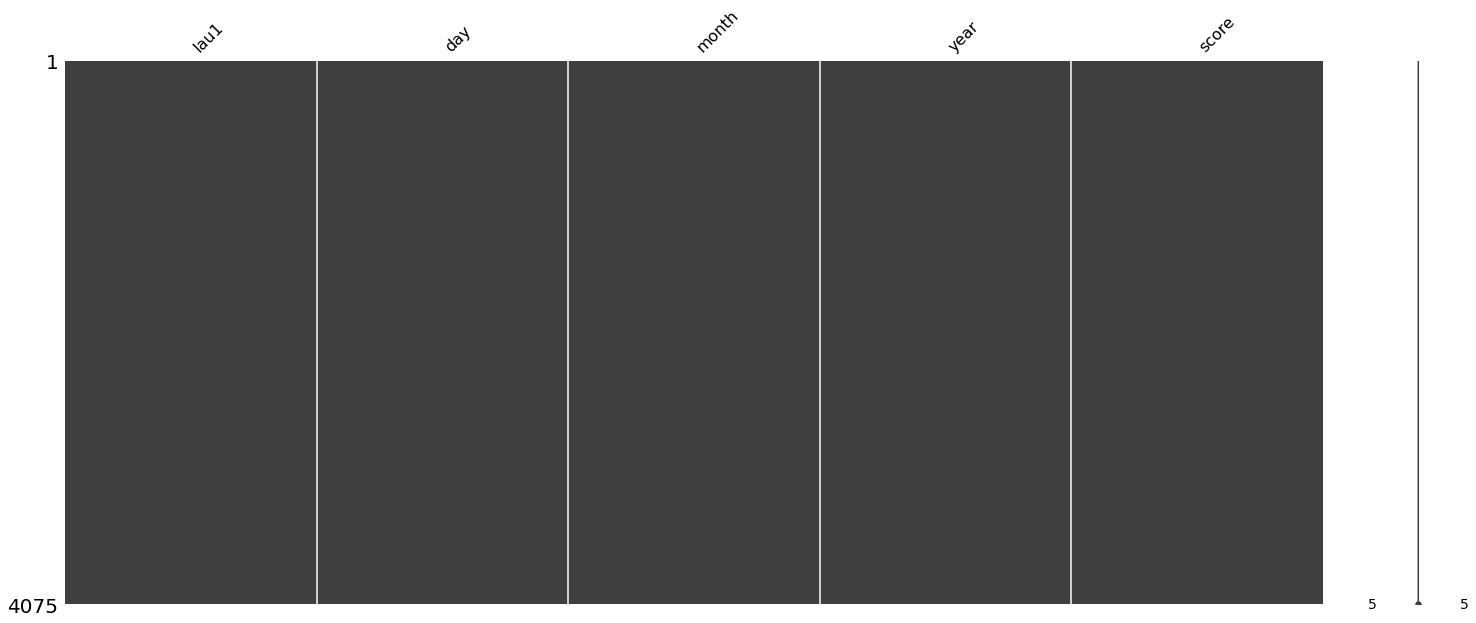

In [20]:
missingno.matrix(concated)

In [21]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [22]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10], dtype=int64)

In [23]:
years = np.sort(concated.year.unique())
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int64)

In [24]:
df = concated[(concated['month'] >= 5) & (concated['month'] <= 8)].copy()

In [25]:
condition = df[(df['month'] == 8) & (df['day'] == 16)].index
df.drop(condition, inplace = True)
df

,lau1,day,month,year,score
0,λιμνης πλαστηρα,1,8,2015,0.991311
4,λαρισαιων,16,7,2012,0.983873
5,λαρισαιων,1,8,2015,0.981968
10,λαρισαιων,1,8,2012,0.977144
12,λαρισαιων,1,8,2021,0.973757
...,...,...,...,...,...
4070,φαρσαλων,16,5,2023,0.000113
4071,νοτιου πηλιου,16,5,2023,0.000063
4072,αλμυρου,16,5,2023,0.000024
4073,σκιαθου,16,5,2023,0.000015


In [26]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_2023.csv'

bins = []

with open(bins_path, mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        bins.extend(map(float, row))

print(bins)

[0.0, 0.0116270026531367, 0.1092954043641872, 0.3320697672817536, 0.5889019634976456, 0.7796951400251816, 0.8695144950847913, 0.9353394101358422, 0.967799747294584, 0.9814817475498204, 1.0]


In [27]:
df['risk_class'] = pd.cut(df['score'], bins=bins, labels=False, include_lowest=True)
df.head(10)

,lau1,day,month,year,score,risk_class
0,λιμνης πλαστηρα,1,8,2015,0.991311,9
4,λαρισαιων,16,7,2012,0.983873,9
5,λαρισαιων,1,8,2015,0.981968,9
10,λαρισαιων,1,8,2012,0.977144,8
12,λαρισαιων,1,8,2021,0.973757,8
16,λιμνης πλαστηρα,16,7,2012,0.970308,8
18,λαρισαιων,16,7,2021,0.968572,8
19,λιμνης πλαστηρα,1,8,2021,0.968308,8
23,λιμνης πλαστηρα,16,7,2015,0.964276,7
29,τρικκαιων,1,8,2012,0.959662,7


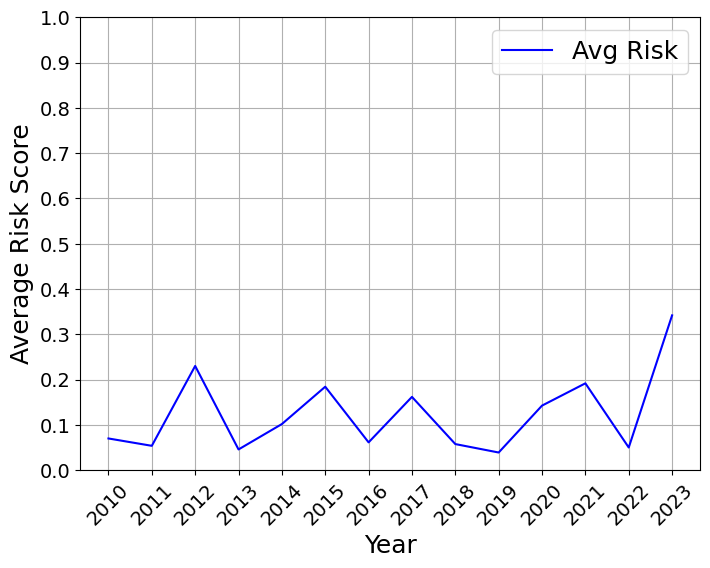

In [28]:
plot_trend_curve(df, plot_max = False, score_col = 'score', plot_cases=False, y_label='Average Risk Score')

In [29]:
risk_2022_over_7 = df[(df['year'] == 2022) & (df['risk_class'] >= 7)].copy()
risk_2022_over_7.reset_index(drop = True, inplace = True)
risk_2022_over_7

,lau1,day,month,year,score,risk_class


In [30]:
risk_2023_over_7 = df[(df['year'] == 2023) & (df['risk_class'] >= 7)].copy()
risk_2023_over_7.reset_index(drop = True, inplace = True)
risk_2023_over_7

,lau1,day,month,year,score,risk_class
0,ελασσονας,1,8,2023,0.999946,9
1,λαρισαιων,1,8,2023,0.999497,9
2,τεμπων,1,8,2023,0.999485,9
3,κιλελερ,1,8,2023,0.998895,9
4,τρικκαιων,1,8,2023,0.997735,9
5,τυρναβου,1,8,2023,0.996441,9
6,φαρσαλων,1,8,2023,0.994995,9
7,φαρκαδονας,1,8,2023,0.994417,9
8,λιμνης πλαστηρα,1,8,2023,0.993416,9
9,καρδιτσας,1,8,2023,0.975295,8
